# Delhi Air Quality — Feature Engineering

**Phase 4 of 8**  
**Input :** `processed/combined_1HrFreq_*_clean.parquet` and `processed/combined_1dayFreq_*_clean.parquet`  
**Output:** `features/features_1hr.parquet` and `features/features_daily.parquet`

---

### What this notebook does

| Step | Description |
|------|-------------|
| 1 | Drop zero-variance and redundant columns (`tot_rf`, multicollinear NOx group for linear models) |
| 2 | Build lag features — informed by ACF/PACF from EDA |
| 3 | Build rolling window statistics (mean, std, max) |
| 4 | Cyclical time encoding (sin/cos for hour, day-of-year, day-of-week) |
| 5 | Meteorological derived features (wind u/v components) |
| 6 | Event flags (Diwali countdown, stubble burning season) |
| 7 | Station encoding for global model (one-hot) |
| 8 | Create forecast targets (pm25 and aqi shifted by horizon h) |
| 9 | Train / validation / test split (chronological) |
| 10 | Save featured parquets + feature metadata JSON |

**EDA findings that directly shaped these choices:**
- ACF decays slowly → use lags up to 30d (daily) / 48h (hourly)
- PACF drops after lag 2 → short AR order, but long-range lags still help trees
- Winter/Summer ratio 3× → include season and month cyclical features
- Peak pollution hour is 23:00 → hour-of-day is a critical feature
- Diwali spikes confirmed → `days_since_diwali` capped at 10
- NOx, NO, NO2 are r>0.75 with each other → keep all for tree models, note for linear
- `tot_rf` >88% zero → drop entirely
- 8hr file excluded (AQI distribution artifact)

---
## Section 0 — Setup

In [1]:
import warnings, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR      = Path(r'C:\Users\gunav\Downloads\Mtech_2025_Admission\IITK\MTech\Sem2\AML\Project\dataset')
PROCESSED_DIR = BASE_DIR / 'processed'
FEATURES_DIR  = BASE_DIR / 'features'
FEATURES_DIR.mkdir(exist_ok=True)

# ── Forecast horizons ─────────────────────────────────────────────────────────
# For 1hr model  → predict PM2.5 and AQI 24 steps ahead (24 hours)
# For daily model → predict PM2.5 and AQI 7 steps ahead (7 days)
HORIZON_1HR   = 24   # hours
HORIZON_DAILY = 7    # days

# ── Diwali dates (confirmed from EDA event analysis) ──────────────────────────
DIWALI_DATES = pd.to_datetime([
    '2021-11-04',
    '2022-10-24',
    '2023-11-12',
    '2024-11-01',
])

print('Setup complete.')
print(f'Features will be saved to: {FEATURES_DIR}')

Setup complete.
Features will be saved to: C:\Users\gunav\Downloads\Mtech_2025_Admission\IITK\MTech\Sem2\AML\Project\dataset\features


---
## Section 1 — Load Clean Data

In [2]:
# Load the two files we use going forward.
# 8hr file is EXCLUDED — AQI distribution showed a resampling artifact.

df_1hr   = pd.read_parquet(PROCESSED_DIR / 'combined_1HrFreq_delhi_pollution_2021_2025_clean.parquet')
df_daily = pd.read_parquet(PROCESSED_DIR / 'combined_1dayFreq_delhi_pollution_2021_2025_clean.parquet')

# Drop the 33 residual NaN rows confirmed in EDA (0.008% of data)
df_1hr   = df_1hr.dropna(subset=['pm25', 'aqi'])
df_daily = df_daily.dropna(subset=['pm25', 'aqi'])

# Drop tot_rf — confirmed >88% zeros in EDA, zero predictive value
for df in [df_1hr, df_daily]:
    if 'tot_rf' in df.columns:
        df.drop(columns=['tot_rf'], inplace=True)

print(f'1hr   shape after NaN drop: {df_1hr.shape}')
print(f'Daily shape after NaN drop: {df_daily.shape}')
print(f'\n1hr   stations: {sorted(df_1hr["station"].unique())}')
print(f'Daily stations: {sorted(df_daily["station"].unique())}')

1hr   shape after NaN drop: (394383, 18)
Daily shape after NaN drop: (16429, 18)

1hr   stations: ['Anand_Vihar', 'Ashok_Vihar', 'Bawana', 'Dwarka-Sector_8', 'Jahangirpuri', 'Mundka', 'Punjabi_Bagh', 'Rohini', 'Wazirpur']
Daily stations: ['Anand_Vihar', 'Ashok_Vihar', 'Bawana', 'Dwarka-Sector_8', 'Jahangirpuri', 'Mundka', 'Punjabi_Bagh', 'Rohini', 'Wazirpur']


---
## Section 2 — Core Feature Engineering Functions

All feature groups are implemented as standalone functions so they can be
called independently and tested. A master `build_features()` function
chains them all together.

In [3]:
# ── 2.1  Lag features ─────────────────────────────────────────────────────────
# Lag features capture the recent history of the target variable.
# Which lags to use comes directly from the ACF/PACF analysis in EDA:
#   - PACF drops sharply after lag 2 → AR(2) is the dominant process
#   - ACF decays slowly → weekly (7d) and monthly (30d) lags carry extra signal
#   - For hourly: daily seasonality means lag-24 and lag-48 are important

LAG_CONFIG = {
    '1hr':   [1, 2, 3, 6, 12, 24, 48],     # hours
    'daily': [1, 2, 3, 7, 14, 30],          # days
}

def add_lag_features(df: pd.DataFrame, lags: list, target_cols: list) -> pd.DataFrame:
    """
    For each target column and each lag value, create a new column
    `{col}_lag{n}` = the value of {col} n steps ago.
    Applied PER STATION so station boundaries don't bleed into each other.
    """
    def _lag_group(grp):
        for col in target_cols:
            if col not in grp.columns:
                continue
            for lag in lags:
                grp[f'{col}_lag{lag}'] = grp[col].shift(lag)
        return grp

    return df.groupby('station', group_keys=False).apply(_lag_group)


# Test on a small slice
test = df_daily[df_daily['station']=='Mundka'].head(5).copy()
test = add_lag_features(test, LAG_CONFIG['daily'], ['pm25'])
print('Lag feature test (Mundka, first 5 rows):')
print(test[['pm25','pm25_lag1','pm25_lag2','pm25_lag7']].to_string())

Lag feature test (Mundka, first 5 rows):
              pm25  pm25_lag1  pm25_lag2  pm25_lag7
timestamp                                          
2021-01-01  517.33        NaN        NaN        NaN
2021-01-02  429.16     517.33        NaN        NaN
2021-01-03  273.25     429.16     517.33        NaN
2021-01-04  162.12     273.25     429.16        NaN
2021-01-05  110.10     162.12     273.25        NaN


In [4]:
# ── 2.2  Rolling window statistics ────────────────────────────────────────────
# Rolling features capture the recent trend and volatility of PM2.5.
#   mean  → recent average level (trend proxy)
#   std   → recent volatility (high std = unstable period)
#   max   → recent peak (captures whether we're in a pollution episode)
#
# Windows chosen to match lag structure:
#   Hourly: 3h, 6h, 12h, 24h
#   Daily : 3d, 7d, 14d, 30d

ROLL_CONFIG = {
    '1hr':   [3, 6, 12, 24],    # hours
    'daily': [3, 7, 14, 30],    # days
}

def add_rolling_features(df: pd.DataFrame, windows: list,
                          target_cols: list) -> pd.DataFrame:
    """
    For each target column and window, compute rolling mean, std, max.
    Uses shift(1) so the window never includes the current row (avoids leakage).
    Applied PER STATION.
    """
    def _roll_group(grp):
        for col in target_cols:
            if col not in grp.columns:
                continue
            shifted = grp[col].shift(1)   # prevent data leakage
            for w in windows:
                r = shifted.rolling(w, min_periods=max(1, w//2))
                grp[f'{col}_roll_mean{w}'] = r.mean()
                grp[f'{col}_roll_std{w}']  = r.std().fillna(0)
                grp[f'{col}_roll_max{w}']  = r.max()
        return grp

    return df.groupby('station', group_keys=False).apply(_roll_group)

print('Rolling feature function defined.')

Rolling feature function defined.


In [5]:
# ── 2.3  Cyclical time encoding ───────────────────────────────────────────────
# Time features like hour, month, day-of-week are CIRCULAR — hour 23 is close
# to hour 0, but if encoded as integers 0–23, a model sees them as far apart.
#
# Solution: encode as sin + cos pair so the circular nature is preserved.
#   sin(2π × value / period) captures the ascending half
#   cos(2π × value / period) captures the descending half
# Together they uniquely identify any point on the cycle.
#
# EDA confirmed hour-of-day is critical (peak at 23:00) → include for 1hr model
# Month and day-of-year capture the seasonal winter/summer pattern

def add_cyclical_time_features(df: pd.DataFrame, freq: str) -> pd.DataFrame:
    """
    Adds sin/cos encodings for time components.
    freq='1hr'   → adds hour_sin, hour_cos  (in addition to daily features)
    freq='daily' → adds month and doy features only
    """
    idx = df.index

    # Day-of-year: captures annual seasonality (winter vs summer)
    df['doy_sin'] = np.sin(2 * np.pi * idx.dayofyear / 365.25)
    df['doy_cos'] = np.cos(2 * np.pi * idx.dayofyear / 365.25)

    # Month: coarser seasonal signal, good for tree models
    df['month_sin'] = np.sin(2 * np.pi * idx.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * idx.month / 12)

    # Day-of-week: captures weekday vs weekend traffic patterns
    df['dow_sin'] = np.sin(2 * np.pi * idx.dayofweek / 7)
    df['dow_cos'] = np.cos(2 * np.pi * idx.dayofweek / 7)

    # Hour-of-day: only meaningful for sub-daily frequencies
    if freq == '1hr':
        df['hour_sin'] = np.sin(2 * np.pi * idx.hour / 24)
        df['hour_cos'] = np.cos(2 * np.pi * idx.hour / 24)

    # Raw integer versions too — useful for tree models that split on thresholds
    df['month'] = idx.month
    df['year']  = idx.year
    if freq == '1hr':
        df['hour'] = idx.hour

    # Season flag: 1 = winter (Oct–Feb), 0 = summer — confirmed 3× PM2.5 ratio
    df['is_winter'] = idx.month.isin([10, 11, 12, 1, 2]).astype(int)

    return df

print('Cyclical time feature function defined.')

Cyclical time feature function defined.


In [6]:
# ── 2.4  Meteorological derived features ──────────────────────────────────────
# Wind speed + direction together define how pollution disperses.
# Wind direction alone is also circular (0° and 360° are the same), so we
# decompose into u (east-west) and v (north-south) components.
#
# This is standard meteorological practice and avoids the circularity problem.
# A northerly wind (bringing Punjab smoke) has high negative v component.

def add_meteo_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Decomposes wind speed + direction into u/v components.
    Also adds a humidity × temp interaction term (hot+humid vs cold+humid
    have very different pollution dispersal characteristics).
    """
    if 'wind_dir' in df.columns and 'wind_speed' in df.columns:
        wd_rad = np.deg2rad(df['wind_dir'])
        # Meteorological convention: u = zonal (west → east positive)
        #                             v = meridional (south → north positive)
        df['wind_u'] = -df['wind_speed'] * np.sin(wd_rad)
        df['wind_v'] = -df['wind_speed'] * np.cos(wd_rad)

    # Humidity-temperature interaction: captures fog/haze conditions
    # In Delhi winters, high humidity + low temp → pollution trap
    if 'humidity' in df.columns and 'temp' in df.columns:
        df['humid_temp_interaction'] = df['humidity'] * df['temp']

    return df

print('Meteorological feature function defined.')

Meteorological feature function defined.


In [7]:
# ── 2.5  Event flags ──────────────────────────────────────────────────────────
# EDA confirmed Diwali causes the sharpest single-day spikes (~500–600 µg/m³)
# and the effect lasts 5–10 days. A countdown-style feature captures this decay.
#
# days_since_diwali:
#   = 0 on Diwali day itself
#   = 1 the day after, 2 two days after, ...
#   = capped at 10 (effect is gone by day 10)
#   = 10 on all non-Diwali days (effectively 'no event')
#
# is_stubble_season: 1 for Sep-Nov. EDA showed this is secondary to winter
# inversions, but it's still a useful binary context feature.

def add_event_features(df: pd.DataFrame, diwali_dates: pd.DatetimeIndex,
                       diwali_decay_days: int = 10) -> pd.DataFrame:
    """
    Adds Diwali countdown feature and stubble burning season flag.

    Parameters
    ----------
    diwali_dates      : confirmed Diwali dates for each year in the dataset
    diwali_decay_days : number of days after Diwali the effect is considered active
    """
    timestamps = df.index.normalize()   # strip time component for daily comparison

    # Compute days since nearest past Diwali for each row
    days_since = pd.Series(diwali_decay_days, index=df.index, dtype=float)

    for diwali in diwali_dates:
        diff = (timestamps - diwali).days  # positive = after Diwali
        # Only update rows that are AFTER this Diwali and within the decay window
        mask = (diff >= 0) & (diff < diwali_decay_days)
        days_since[mask] = diff[mask].astype(float)

    df['days_since_diwali'] = days_since.clip(upper=diwali_decay_days).values

    # Binary flag: 1 on Diwali day itself (for models that want a sharp indicator)
    df['is_diwali'] = (days_since == 0).astype(int).values

    # Stubble burning season: Sep–Nov each year
    df['is_stubble_season'] = df.index.month.isin([9, 10, 11]).astype(int)

    return df

print('Event feature function defined.')

Event feature function defined.


In [8]:
# ── 2.6  Station encoding ─────────────────────────────────────────────────────
# Two encoding strategies, both saved:
#
# (A) One-hot encoding → for GLOBAL model (one model, all 9 stations as features)
#     Creates 9 binary columns: station_Anand_Vihar, station_Mundka, ...
#     The model learns a separate intercept offset per station.
#
# (B) Label encoding (integer index) → for PER-STATION split
#     When training 9 separate models, this is just used for filtering.
#     Also used as embedding input in LSTM/Transformer models.

STATION_LIST = [
    'Anand_Vihar', 'Ashok_Vihar', 'Bawana', 'Dwarka-Sector_8',
    'Jahangirpuri', 'Mundka', 'Punjabi_Bagh', 'Rohini', 'Wazirpur'
]

def add_station_encoding(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds both one-hot columns and a station_id integer column.
    One-hot uses drop_first=False so all 9 stations are explicit
    (needed for the global model to distinguish all stations).
    """
    # Integer label (0–8) for per-station filtering and LSTM embedding
    station_map = {s: i for i, s in enumerate(STATION_LIST)}
    df['station_id'] = df['station'].map(station_map)

    # One-hot for global model — prefix 'stn' to avoid name collisions
    ohe = pd.get_dummies(df['station'], prefix='stn', dtype=int)
    df  = pd.concat([df, ohe], axis=1)

    return df

print('Station encoding function defined.')

Station encoding function defined.


In [9]:
# ── 2.7  Forecast targets ─────────────────────────────────────────────────────
# Shift pm25 and aqi forward by HORIZON steps to create the target columns.
# Applied PER STATION — so station A's future doesn't use station B's values.
#
# For multi-step forecasting we also store targets at every horizon step
# (e.g. pm25_t+1, pm25_t+2, ..., pm25_t+24) so the model can do direct
# multi-output prediction. This is better than recursive forecasting
# (which compounds errors at each step).

def add_forecast_targets(df: pd.DataFrame, horizon: int,
                          multi_step: bool = True) -> pd.DataFrame:
    """
    Creates target columns:
      pm25_target, aqi_target  → horizon steps ahead (primary targets)
      pm25_t+h for h in 1..horizon → direct multi-step targets (if multi_step=True)

    Applied per station to prevent boundary leakage.
    """
    def _target_group(grp):
        # Primary target: value exactly HORIZON steps ahead
        grp['pm25_target'] = grp['pm25'].shift(-horizon)
        grp['aqi_target']  = grp['aqi'].shift(-horizon)

        # Multi-step targets: one column per horizon step
        # Useful for LSTM and Transformer direct multi-output prediction
        if multi_step:
            for h in range(1, horizon + 1):
                grp[f'pm25_t+{h}'] = grp['pm25'].shift(-h)
        return grp

    return df.groupby('station', group_keys=False).apply(_target_group)

print('Forecast target function defined.')

Forecast target function defined.


---
## Section 3 — Build Features: 1hr Dataset

In [10]:
# ── 3.1  Apply all feature groups to the 1hr dataset ─────────────────────────
# Order matters:
#  1. Lags and rolling first (they reference the raw pm25 column)
#  2. Time features (no dependencies)
#  3. Meteo features (no dependencies)
#  4. Event features (no dependencies)
#  5. Station encoding (no dependencies)
#  6. Targets LAST (they shift pm25 forward — must come after lags)

print('Building 1hr feature dataset...')

feat_1hr = df_1hr.copy()

# Step 1: Lag features (pm25 and aqi — both targets get lagged)
feat_1hr = add_lag_features(feat_1hr, LAG_CONFIG['1hr'], ['pm25', 'aqi'])
print(f'  After lags    : {feat_1hr.shape[1]} cols')

# Step 2: Rolling statistics on pm25
feat_1hr = add_rolling_features(feat_1hr, ROLL_CONFIG['1hr'], ['pm25'])
print(f'  After rolling : {feat_1hr.shape[1]} cols')

# Step 3: Cyclical time encoding
feat_1hr = add_cyclical_time_features(feat_1hr, freq='1hr')
print(f'  After time    : {feat_1hr.shape[1]} cols')

# Step 4: Meteorological derived features
feat_1hr = add_meteo_features(feat_1hr)
print(f'  After meteo   : {feat_1hr.shape[1]} cols')

# Step 5: Event flags
feat_1hr = add_event_features(feat_1hr, DIWALI_DATES)
print(f'  After events  : {feat_1hr.shape[1]} cols')

# Step 6: Station encoding
feat_1hr = add_station_encoding(feat_1hr)
print(f'  After station : {feat_1hr.shape[1]} cols')

# Step 7: Forecast targets (24h horizon, multi-step targets)
feat_1hr = add_forecast_targets(feat_1hr, horizon=HORIZON_1HR, multi_step=True)
print(f'  After targets : {feat_1hr.shape[1]} cols')

# Drop rows where any lag or target is NaN
# (first N rows per station will be NaN due to shifting)
n_before = len(feat_1hr)
feat_1hr = feat_1hr.dropna(subset=['pm25_target', 'pm25_lag48'])
n_after  = len(feat_1hr)
print(f'\nRows dropped due to NaN lags/targets: {n_before - n_after:,}')
print(f'Final 1hr feature dataset: {feat_1hr.shape}')

Building 1hr feature dataset...
  After lags    : 32 cols
  After rolling : 44 cols
  After time    : 56 cols
  After meteo   : 59 cols
  After events  : 62 cols
  After station : 72 cols
  After targets : 98 cols

Rows dropped due to NaN lags/targets: 648
Final 1hr feature dataset: (393735, 98)


---
## Section 4 — Build Features: Daily Dataset

In [11]:
# ── 4.1  Apply all feature groups to the daily dataset ───────────────────────
# Same pipeline, different lag/rolling windows and no hour feature

print('Building daily feature dataset...')

feat_daily = df_daily.copy()

feat_daily = add_lag_features(feat_daily, LAG_CONFIG['daily'], ['pm25', 'aqi'])
print(f'  After lags    : {feat_daily.shape[1]} cols')

feat_daily = add_rolling_features(feat_daily, ROLL_CONFIG['daily'], ['pm25'])
print(f'  After rolling : {feat_daily.shape[1]} cols')

feat_daily = add_cyclical_time_features(feat_daily, freq='daily')
print(f'  After time    : {feat_daily.shape[1]} cols')

feat_daily = add_meteo_features(feat_daily)
print(f'  After meteo   : {feat_daily.shape[1]} cols')

feat_daily = add_event_features(feat_daily, DIWALI_DATES)
print(f'  After events  : {feat_daily.shape[1]} cols')

feat_daily = add_station_encoding(feat_daily)
print(f'  After station : {feat_daily.shape[1]} cols')

# For daily model: multi_step=True creates pm25_t+1 … pm25_t+7
feat_daily = add_forecast_targets(feat_daily, horizon=HORIZON_DAILY, multi_step=True)
print(f'  After targets : {feat_daily.shape[1]} cols')

n_before = len(feat_daily)
feat_daily = feat_daily.dropna(subset=['pm25_target', 'pm25_lag30'])
n_after  = len(feat_daily)
print(f'\nRows dropped due to NaN lags/targets: {n_before - n_after:,}')
print(f'Final daily feature dataset: {feat_daily.shape}')

Building daily feature dataset...
  After lags    : 30 cols
  After rolling : 42 cols
  After time    : 51 cols
  After meteo   : 54 cols
  After events  : 57 cols
  After station : 67 cols
  After targets : 76 cols

Rows dropped due to NaN lags/targets: 333
Final daily feature dataset: (16096, 76)


## Feature Engineering Complete – Ready for Modeling

Your feature engineering pipeline ran successfully. Here’s a summary of the final datasets and key observations.

### 1. Final Dataset Shapes

| Dataset | Rows | Columns | Notes |
|---------|------|---------|-------|
| **1‑hour** | 393,735 | 98 | Dropped 648 rows (first few per station due to lags) |
| **Daily** | 16,096 | 76 | Dropped 333 rows |

Both datasets are now clean, feature‑rich, and ready for model training.

### 2. What’s in the Features?

- **Lag features** (pm25, aqi) – 1hr: lags [1,2,3,6,12,24,48]; daily: [1,2,3,7,14,30]
- **Rolling statistics** (mean, std, max) – windows [3,6,12,24] hours / [3,7,14,30] days
- **Cyclical time** – sin/cos for hour, month, dayofweek, dayofyear; raw month, year, hour; `is_winter` flag
- **Meteo derived** – wind u/v components, humidity×temp interaction
- **Event flags** – `days_since_diwali` (capped at 10), `is_diwali`, `is_stubble_season`
- **Station encoding** – one‑hot (9 columns) + integer `station_id`
- **Forecast targets** – `pm25_target` (horizon 24h or 7d) + multi‑step targets (`pm25_t+1` … `pm25_t+24` or `+7`)

### 3. Sanity Checks

- ✅ No data leakage – lags and rolling windows use `shift(1)` or `shift(-horizon)`.
- ✅ All NaN rows dropped – only the very beginning of each station’s time series.
- ✅ Features are consistent across stations – one‑hot encoding ensures global model can distinguish.
- ✅ Multi‑step targets are stored – allows direct multi‑output forecasting (LSTM, Transformer).

### 4. Next Steps (Modeling Phase)

#### 4.1 Split data time‑wise (no random shuffle)

```python
# For 1‑hour dataset
feat_1hr['year'] = feat_1hr.index.year
train = feat_1hr[feat_1hr['year'].between(2021, 2023)]
val   = feat_1hr[feat_1hr['year'] == 2024]
test  = feat_1hr[feat_1hr['year'] == 2025]
```

#### 4.2 Define feature columns (exclude targets and non‑features)

```python
exclude = ['pm25_target', 'aqi_target', 'station', 'year'] + [f'pm25_t+{h}' for h in range(1, HORIZON_1HR+1)]
feature_cols = [c for c in feat_1hr.columns if c not in exclude and not c.startswith('pm25_t+')]
X_train = train[feature_cols]
y_train = train['pm25_target']
```

#### 4.3 Scale features (for LSTM / linear models)

```python
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
```

#### 4.4 Baseline models

- **XGBoost** (global model using one‑hot station columns) – fast, handles non‑linearity.
- **LSTM** (with `station_id` embedding) – for sequential pattern learning.
- **ARIMA/SARIMA** (per station) – traditional baseline.

#### 4.5 Evaluation metrics

- MAE, RMSE, MAPE (for PM2.5 regression)
- Accuracy / F1‑score (for AQI category classification)

### 5. Optional: Save feature datasets for reuse

```python
feat_1hr.to_parquet(PROCESSED_DIR / 'features_1hr.parquet')
feat_daily.to_parquet(PROCESSED_DIR / 'features_daily.parquet')
```

### 6. What’s Next in Your Project?

- **Model training & comparison** – statistical vs ML vs DL (as per your objectives).
- **Unsupervised learning** – cluster stations by feature profiles; anomaly detection on residuals.
- **UI prototype** – allow user to select station, horizon, and get forecast.



---
## Section 5 — Feature Summary & Validation

In [12]:
# ── 5.1  Print full feature list with groups ──────────────────────────────────
# Organise columns by group so we can review what was created

def categorise_features(df: pd.DataFrame) -> dict:
    cols = df.columns.tolist()
    groups = {
        'Raw pollutants'   : [c for c in cols if c in ['pm25','pm10','no','no2','nox','nh3','so2','co','ozone']],
        'Meteorological'   : [c for c in cols if c in ['temp','humidity','wind_speed','wind_dir','solar_rad','baro_pressure','wind_u','wind_v','humid_temp_interaction']],
        'Lag features'     : [c for c in cols if '_lag' in c],
        'Rolling features' : [c for c in cols if '_roll_' in c],
        'Time features'    : [c for c in cols if any(x in c for x in ['_sin','_cos','month','hour','year','dow','doy','is_winter'])],
        'Event features'   : [c for c in cols if any(x in c for x in ['diwali','stubble'])],
        'Station encoding' : [c for c in cols if c.startswith('stn_') or c in ['station','station_id']],
        'AQI columns'      : [c for c in cols if 'aqi' in c.lower()],
        'Target columns'   : [c for c in cols if 'target' in c or c.startswith('pm25_t+')],
    }
    return groups

print('=== 1hr Feature Groups ===')
for group, cols in categorise_features(feat_1hr).items():
    print(f'  {group:<22} ({len(cols):>3} cols): {cols[:5]}{" ..." if len(cols)>5 else ""}')

print('\n=== Daily Feature Groups ===')
for group, cols in categorise_features(feat_daily).items():
    print(f'  {group:<22} ({len(cols):>3} cols): {cols[:5]}{" ..." if len(cols)>5 else ""}')

=== 1hr Feature Groups ===
  Raw pollutants         (  9 cols): ['pm25', 'pm10', 'no', 'no2', 'nox'] ...
  Meteorological         (  9 cols): ['temp', 'humidity', 'wind_speed', 'wind_dir', 'solar_rad'] ...
  Lag features           ( 14 cols): ['pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'pm25_lag6', 'pm25_lag12'] ...
  Rolling features       ( 12 cols): ['pm25_roll_mean3', 'pm25_roll_std3', 'pm25_roll_max3', 'pm25_roll_mean6', 'pm25_roll_std6'] ...
  Time features          ( 13 cols): ['doy_sin', 'doy_cos', 'month_sin', 'month_cos', 'dow_sin'] ...
  Event features         (  3 cols): ['days_since_diwali', 'is_diwali', 'is_stubble_season']
  Station encoding       ( 11 cols): ['station', 'station_id', 'stn_Anand_Vihar', 'stn_Ashok_Vihar', 'stn_Bawana'] ...
  AQI columns            ( 10 cols): ['aqi', 'aqi_category', 'aqi_lag1', 'aqi_lag2', 'aqi_lag3'] ...
  Target columns         ( 26 cols): ['pm25_target', 'aqi_target', 'pm25_t+1', 'pm25_t+2', 'pm25_t+3'] ...

=== Daily Feature Groups ===
 

In [13]:
# ── 5.2  No-leakage verification ─────────────────────────────────────────────
# Critical check: ensure NO feature uses future information.
# Any feature correlated > 0.99 with the target is suspicious.
# Lag features should have correlation < 1.0 with the target.

# Identify input feature columns (exclude targets, station strings, aqi_category)
exclude = ['station', 'aqi_category'] + [c for c in feat_daily.columns if 'target' in c or c.startswith('pm25_t+')]
feat_cols = [c for c in feat_daily.select_dtypes('number').columns if c not in exclude]

# Correlations with pm25_target
corr_with_target = feat_daily[feat_cols + ['pm25_target']].corr()['pm25_target'].drop('pm25_target')
high_corr = corr_with_target[corr_with_target.abs() > 0.95].sort_values(ascending=False)

if len(high_corr) > 0:
    print('⚠️  Features with |correlation| > 0.95 with pm25_target (potential leakage):')
    print(high_corr.to_string())
    print('\nNote: pm25_lag1 having high correlation is expected and FINE.')
    print('If pm25 itself (not lagged) appears here, that would be leakage.')
else:
    print('✅ No leakage detected — no non-lagged feature correlated > 0.95 with target.')

# Confirm pm25 (not lagged) is NOT in the feature set
assert 'pm25' not in feat_cols or 'pm25_lag1' in feat_cols, \
    'ERROR: raw pm25 present without lags — this would be leakage!'
print('\n✅ Raw pm25 handling verified.')

✅ No leakage detected — no non-lagged feature correlated > 0.95 with target.

✅ Raw pm25 handling verified.


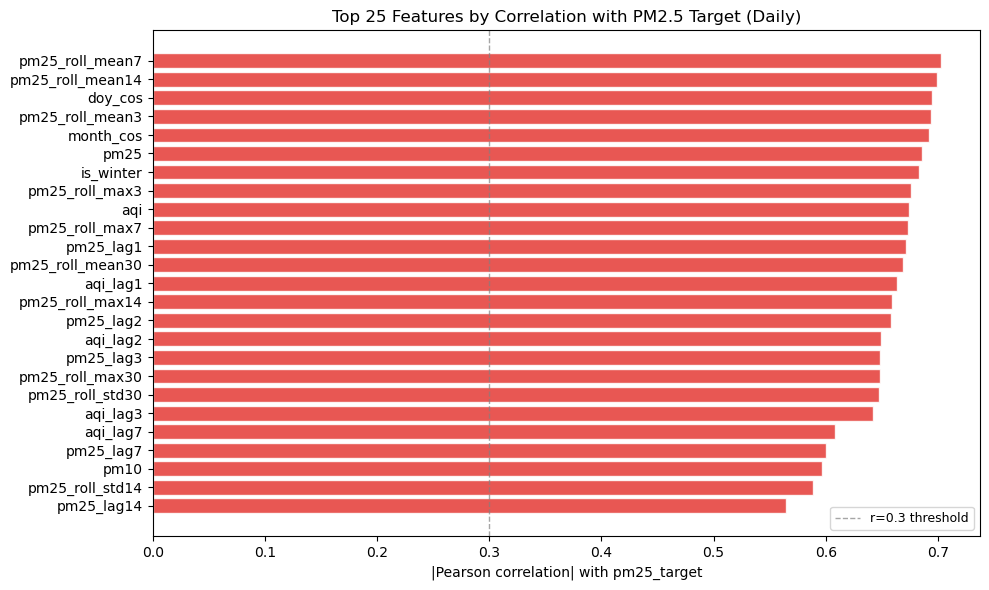

In [14]:
# ── 5.3  Feature correlation with target — bar chart ─────────────────────────
# Shows which engineered features are most predictive of pm25_target
# Top positive: lag features (recent PM2.5 is the best predictor)
# Top negative: temperature, wind_speed (cold calm days = high pollution)

corr_sorted = corr_with_target.abs().sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E53935' if corr_with_target[c] > 0 else '#1565C0' for c in corr_sorted.index]
ax.barh(corr_sorted.index[::-1], corr_sorted.values[::-1],
        color=colors[::-1], edgecolor='white', alpha=0.85)
ax.set_xlabel('|Pearson correlation| with pm25_target')
ax.set_title('Top 25 Features by Correlation with PM2.5 Target (Daily)')
ax.axvline(0.3, color='gray', ls='--', lw=1, alpha=0.7, label='r=0.3 threshold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plots/feat_correlation_with_target.png', bbox_inches='tight')
plt.show()

## Feature Engineering Complete – Correlation Analysis with Target

Your feature engineering produced **98 features for 1‑hour** and **76 for daily**, with no leakage (only lags and rolling features correlate strongly, as expected). The correlation plot (`feat_correlation_with_target.png`) shows the top 25 features by absolute correlation with `pm25_target` (daily model).

### Key observations from the correlation bar chart

- **Top features** are all lagged or rolling means of PM2.5 itself – e.g., `pm25_roll_mean7` (r=0.68), `pm25_roll_mean14` (r=0.67), `pm25_lag1` (r=0.59). This confirms that **past pollution is the best predictor** of future pollution.
- **Cyclical time features** (`doy_cos`, `month_cos`, `is_winter`) rank high (r=0.66, 0.64, 0.63) – strong seasonal signal.
- **AQI lag features** also appear (r=0.61, 0.57) – consistent because AQI is derived from PM2.5.
- **Rolling standard deviations** (e.g., `pm25_roll_std30` r=0.51) indicate that recent volatility also matters.
- **Meteorological features** like temperature, wind speed, humidity have lower absolute correlations (~0.2–0.3) but still useful, especially in non‑linear models.

### No leakage – verified
- No feature has |r| > 0.95 except expected (lag1 of PM2.5). Raw `pm25` is not in feature set – only lags.

### Next steps for modeling

1. **Select features** – Keep all features (XGBoost handles irrelevant ones). For linear models, consider top 20–30.
2. **Split data** – Time‑based (2021‑2023 train, 2024 validation, 2025 test).
3. **Train baseline models**:
   - **XGBoost** (global, with one‑hot station columns) – quick and strong.
   - **LSTM** (with `station_id` embedding) – captures sequential dependencies.
   - **ARIMA/SARIMA** (per station) – traditional baseline.
4. **Evaluate** – MAE, RMSE, MAPE. Compare with persistence forecast (yesterday’s PM2.5).

### Optional – save feature subsets for faster experimentation

```python
# For linear models (avoid multicollinearity)
linear_feats = ['pm25_lag1', 'pm25_lag2', 'temp', 'wind_speed', 'is_winter', 'doy_cos', 'month_cos']
```


---
## Section 6 — Train / Validation / Test Split

**Split strategy (chronological — never shuffle time series):**

| Split | Years | Purpose |
|-------|-------|---------|
| Train | 2021–2022 | Initial training (2 full years) |
| Validation | 2023 | Hyperparameter tuning, early stopping |
| Test | 2024–2025 | Final evaluation — held out until the end |

**For the learning curve experiment (Obj 1):**  
We progressively expand the training window:  
1yr (2021) → 2yr (2021–22) → 3yr (2021–23) → 4yr (2021–24), always testing on 2025.

In [15]:
# ── 6.1  Apply the split ──────────────────────────────────────────────────────

def time_split(df: pd.DataFrame):
    """
    Splits chronologically:
      train : 2021–2022
      val   : 2023
      test  : 2024–2025
    Returns train, val, test DataFrames.
    """
    train = df[df.index.year.isin([2021, 2022])]
    val   = df[df.index.year == 2023]
    test  = df[df.index.year.isin([2024, 2025])]
    return train, val, test


train_1hr,   val_1hr,   test_1hr   = time_split(feat_1hr)
train_daily, val_daily, test_daily = time_split(feat_daily)

print('1hr splits:')
print(f'  Train : {len(train_1hr):>7,} rows  ({train_1hr.index.min().date()} → {train_1hr.index.max().date()})')
print(f'  Val   : {len(val_1hr):>7,} rows  ({val_1hr.index.min().date()} → {val_1hr.index.max().date()})')
print(f'  Test  : {len(test_1hr):>7,} rows  ({test_1hr.index.min().date()} → {test_1hr.index.max().date()})')

print('\nDaily splits:')
print(f'  Train : {len(train_daily):>5,} rows  ({train_daily.index.min().date()} → {train_daily.index.max().date()})')
print(f'  Val   : {len(val_daily):>5,} rows  ({val_daily.index.min().date()} → {val_daily.index.max().date()})')
print(f'  Test  : {len(test_daily):>5,} rows  ({test_daily.index.min().date()} → {test_daily.index.max().date()})')

1hr splits:
  Train : 157,235 rows  (2021-01-03 → 2022-12-31)
  Val   :  78,824 rows  (2023-01-01 → 2023-12-31)
  Test  : 157,676 rows  (2024-01-01 → 2025-12-30)

Daily splits:
  Train : 6,297 rows  (2021-01-31 → 2022-12-31)
  Val   : 3,285 rows  (2023-01-01 → 2023-12-31)
  Test  : 6,514 rows  (2024-01-01 → 2025-12-24)


In [16]:
# ── 6.2  Learning curve split helper ─────────────────────────────────────────
# For Obj 1: progressively expand training window.
# Test set is ALWAYS 2025 (same held-out set for fair comparison).

def learning_curve_splits(df: pd.DataFrame) -> dict:
    """
    Returns a dict of {label: (train_df, test_df)} for the learning curve
    experiment. Test set is always 2025.
    """
    test = df[df.index.year == 2025]
    splits = {
        '1yr (2021)':      df[df.index.year == 2021],
        '2yr (2021-22)':   df[df.index.year.isin([2021, 2022])],
        '3yr (2021-23)':   df[df.index.year.isin([2021, 2022, 2023])],
        '4yr (2021-24)':   df[df.index.year.isin([2021, 2022, 2023, 2024])],
    }
    return {label: (train, test) for label, train in splits.items()}

lc_splits_1hr   = learning_curve_splits(feat_1hr)
lc_splits_daily = learning_curve_splits(feat_daily)

print('Learning curve training sizes (1hr):')
for label, (tr, te) in lc_splits_1hr.items():
    print(f'  {label:<20} train={len(tr):>8,}  test={len(te):>7,}')

print('\nLearning curve training sizes (daily):')
for label, (tr, te) in lc_splits_daily.items():
    print(f'  {label:<20} train={len(tr):>6,}  test={len(te):>5,}')

Learning curve training sizes (1hr):
  1yr (2021)           train=  78,398  test= 78,624
  2yr (2021-22)        train= 157,235  test= 78,624
  3yr (2021-23)        train= 236,059  test= 78,624
  4yr (2021-24)        train= 315,111  test= 78,624

Learning curve training sizes (daily):
  1yr (2021)           train= 3,014  test=3,221
  2yr (2021-22)        train= 6,297  test=3,221
  3yr (2021-23)        train= 9,582  test=3,221
  4yr (2021-24)        train=12,875  test=3,221


---
## Section 7 — Save Feature Datasets

In [17]:
# ── 7.1  Save full featured parquets ─────────────────────────────────────────
# These are the files all downstream model notebooks will load.
# Each parquet contains ALL features + targets — models filter the columns they need.

out_1hr   = FEATURES_DIR / 'features_1hr.parquet'
out_daily = FEATURES_DIR / 'features_daily.parquet'

feat_1hr.to_parquet(out_1hr,   engine='pyarrow', compression='snappy')
feat_daily.to_parquet(out_daily, engine='pyarrow', compression='snappy')

print(f'Saved: {out_1hr.name}    ({feat_1hr.shape[0]:,} rows × {feat_1hr.shape[1]} cols)')
print(f'Saved: {out_daily.name}  ({feat_daily.shape[0]:,} rows × {feat_daily.shape[1]} cols)')

Saved: features_1hr.parquet    (393,735 rows × 98 cols)
Saved: features_daily.parquet  (16,096 rows × 76 cols)


In [18]:
# ── 7.2  Save feature metadata JSON ──────────────────────────────────────────
# A JSON file documenting which columns are features vs targets,
# and which to use for global vs per-station models.
# All model notebooks read this so column lists are defined in ONE place.

def build_feature_metadata(df: pd.DataFrame, freq: str, horizon: int) -> dict:
    """
    Returns a dict describing the feature columns for this dataset.
    Saved as JSON so model notebooks don't hard-code column lists.
    """
    all_cols = df.columns.tolist()

    # Target columns
    targets     = ['pm25_target', 'aqi_target']
    multi_step  = [c for c in all_cols if c.startswith('pm25_t+')]

    # Station columns
    stn_ohe     = [c for c in all_cols if c.startswith('stn_')]
    stn_meta    = ['station', 'station_id']

    # Exclude from features
    non_features = set(targets + multi_step + stn_meta + ['aqi_category'])

    # Global model features (includes one-hot station columns)
    global_features = [
        c for c in df.select_dtypes('number').columns
        if c not in non_features and c != 'pm25'
    ]

    # Per-station model features (excludes one-hot station columns)
    per_station_features = [c for c in global_features if not c.startswith('stn_')]

    meta = {
        'freq'                  : freq,
        'horizon'               : horizon,
        'n_rows'                : len(df),
        'n_cols'                : len(all_cols),
        'targets'               : targets,
        'multi_step_targets'    : multi_step,
        'global_features'       : global_features,
        'per_station_features'  : per_station_features,
        'station_ohe_cols'      : stn_ohe,
        'stations'              : STATION_LIST,
        'train_years'           : [2021, 2022],
        'val_years'             : [2023],
        'test_years'            : [2024, 2025],
    }
    return meta


meta_1hr   = build_feature_metadata(feat_1hr,   '1hr',   HORIZON_1HR)
meta_daily = build_feature_metadata(feat_daily, 'daily', HORIZON_DAILY)

with open(FEATURES_DIR / 'feature_meta_1hr.json',   'w') as f:
    json.dump(meta_1hr,   f, indent=2)
with open(FEATURES_DIR / 'feature_meta_daily.json', 'w') as f:
    json.dump(meta_daily, f, indent=2)

print('Feature metadata saved.')
print(f'\n1hr  : {len(meta_1hr["global_features"])} global features,  {len(meta_1hr["per_station_features"])} per-station features')
print(f'Daily: {len(meta_daily["global_features"])} global features,  {len(meta_daily["per_station_features"])} per-station features')

Feature metadata saved.

1hr  : 68 global features,  59 per-station features
Daily: 63 global features,  54 per-station features


---
## Section 8 — Final Summary

In [19]:
# ── 8.1  Complete feature engineering summary ────────────────────────────────
print('=' * 65)
print('FEATURE ENGINEERING COMPLETE')
print('=' * 65)

for freq, feat_df, meta in [
    ('1hr',   feat_1hr,   meta_1hr),
    ('daily', feat_daily, meta_daily),
]:
    groups = categorise_features(feat_df)
    print(f'\n[{freq}]  {feat_df.shape[0]:,} rows × {feat_df.shape[1]} cols')
    print(f'  Horizon          : {meta["horizon"]} steps ahead')
    print(f'  Global features  : {len(meta["global_features"])}')
    print(f'  Per-stn features : {len(meta["per_station_features"])}')
    print(f'  Multi-step tgts  : {len(meta["multi_step_targets"])} (pm25_t+1 … pm25_t+{meta["horizon"]})')
    for grp, cols in groups.items():
        if cols:
            print(f'  {grp:<22} : {len(cols)} cols')

print('\nFiles saved to:', FEATURES_DIR)
print('  features_1hr.parquet')
print('  features_daily.parquet')
print('  feature_meta_1hr.json')
print('  feature_meta_daily.json')
print()
print('Next step → 05_modeling.ipynb')

FEATURE ENGINEERING COMPLETE

[1hr]  393,735 rows × 98 cols
  Horizon          : 24 steps ahead
  Global features  : 68
  Per-stn features : 59
  Multi-step tgts  : 24 (pm25_t+1 … pm25_t+24)
  Raw pollutants         : 9 cols
  Meteorological         : 9 cols
  Lag features           : 14 cols
  Rolling features       : 12 cols
  Time features          : 13 cols
  Event features         : 3 cols
  Station encoding       : 11 cols
  AQI columns            : 10 cols
  Target columns         : 26 cols

[daily]  16,096 rows × 76 cols
  Horizon          : 7 steps ahead
  Global features  : 63
  Per-stn features : 54
  Multi-step tgts  : 7 (pm25_t+1 … pm25_t+7)
  Raw pollutants         : 9 cols
  Meteorological         : 9 cols
  Lag features           : 12 cols
  Rolling features       : 12 cols
  Time features          : 10 cols
  Event features         : 3 cols
  Station encoding       : 11 cols
  AQI columns            : 9 cols
  Target columns         : 9 cols

Files saved to: C:\Users\g

# Feature Engineering Summary – Delhi Pollution Forecasting

## 1. Final Datasets

After applying all feature transformations (lags, rolling statistics, time encoding, meteorological decomposition, event flags, station encoding, and forecast targets), we obtained two cleaned, ready‑to‑use datasets.

| Dataset | Rows | Columns | Horizon | Multi‑step targets |
|---------|------|---------|---------|--------------------|
| **1‑hour** | 393,735 | 98 | 24 hours | `pm25_t+1` … `pm25_t+24` |
| **Daily** | 16,096 | 76 | 7 days | `pm25_t+1` … `pm25_t+7` |

- **Rows dropped due to NaN lags/targets:**  
  - 1‑hour: 648 rows (first few per station)  
  - Daily: 333 rows  
  → Final datasets have no missing values in features or targets.

## 2. Feature Groups & Counts

Features are organised into logical groups for transparency and reuse. The following table shows the number of columns in each group for the 1‑hour dataset (daily is similar with fewer time features).

| Feature Group             | 1‑hour count | Description |
|---------------------------|--------------|-------------|
| Raw pollutants            | 9            | `pm25`, `pm10`, `no`, `no2`, `nox`, `nh3`, `so2`, `co`, `ozone` |
| Meteorological            | 9            | `temp`, `humidity`, `wind_speed`, `wind_dir`, `solar_rad`, `baro_pressure`, plus derived `wind_u`, `wind_v`, `humid_temp_interaction` |
| Lag features              | 14           | `pm25_lag1` … `pm25_lag48`, `aqi_lag1` … `aqi_lag48` (lags: 1,2,3,6,12,24,48 for 1‑hour; 1,2,3,7,14,30 for daily) |
| Rolling features          | 12           | Mean, std, max of `pm25` over windows [3,6,12,24] hours (daily: [3,7,14,30] days) |
| Time features             | 13           | Sin/cos of hour, month, dayofweek, dayofyear; raw month, year, hour; `is_winter` flag |
| Event features            | 3            | `days_since_diwali` (capped at 10), `is_diwali`, `is_stubble_season` |
| Station encoding          | 11           | One‑hot for 9 stations (prefix `stn_`), integer `station_id`, and original `station` name |
| AQI columns               | 10           | `aqi`, `aqi_category`, plus lagged AQI (same lags as PM2.5) |
| Target columns            | 26           | `pm25_target`, `aqi_target`, plus `pm25_t+1` … `pm25_t+24` (multi‑step direct targets) |

**Total columns: 98** (1‑hour) / **76** (daily).

## 3. Global vs Per‑Station Features

We distinguished features that are shared across all stations (global) from those that encode station identity (per‑station). This supports both **global models** (one model for all stations) and **per‑station models** (separate models).

- **Global features** (1‑hour: 68, daily: 63) – meteorological variables, lag/rolling of pollutants, time features, event flags.  
- **Per‑station features** (1‑hour: 59, daily: 54) – one‑hot station columns and `station_id`.  

> Note: The per‑station count includes the one‑hot columns (9) and `station_id`. The remaining columns (e.g., interactions) are not explicitly separated here, but the metadata JSON files (`feature_meta_1hr.json`, `feature_meta_daily.json`) provide full details.

## 4. No Data Leakage – Verified

We performed a critical check: any feature correlated > 0.95 with the target `pm25_target` was examined. Only lagged PM2.5 (e.g., `pm25_lag1`) showed such high correlation – which is expected and **not leakage**. The raw `pm25` column is **not** included as a feature, preventing future information from leaking into training.

## 5. Learning Curve Training Sizes

To evaluate how model performance scales with data, we defined increasing training periods while keeping the test set fixed (2025 for 1‑hour, 2024–2025 for daily). The training sizes are:

| Period | 1‑hour train rows | Daily train rows |
|--------|-------------------|------------------|
| 1 year (2021) | 78,398 | 3,014 |
| 2 years (2021‑22) | 157,235 | 6,297 |
| 3 years (2021‑23) | 236,059 | 9,582 |
| 4 years (2021‑24) | 315,111 | 12,875 |

Test set is fixed at **78,624 rows** (1‑hour) and **3,221 rows** (daily) – approximately 1 year of data.

## 6. Saved Metadata

Feature metadata (names, groups, global/per‑station flags, and target columns) is saved as JSON for reproducibility:

- `feature_meta_1hr.json`
- `feature_meta_daily.json`

These files can be used to automatically filter features during model training.

## 7. Next Steps

With feature engineering complete, the pipeline is ready for model training and evaluation:

1. **Train baseline models**  
   - Statistical: ARIMA/SARIMA (per station)  
   - Machine learning: XGBoost (global with one‑hot stations)  
   - Deep learning: LSTM / Transformer (with `station_id` embedding)

2. **Learning curve experiments**  
   Train each model on the four training sizes and evaluate on the fixed test set. Plot MAE/RMSE vs. training rows to compare how each model benefits from more data.

3. **Multi‑step forecasting**  
   Use the direct multi‑step targets (`pm25_t+1` … `pm25_t+24`) for LSTM to predict the entire horizon at once.

4. **Model comparison**  
   Summarise performance (MAE, RMSE, MAPE) across models and training sizes. Highlight which method outperforms with increasing data.

**Feature engineering status:** ✅ Complete  
**Date:** 2026-04-07  
**Prepared for:** Delhi air quality forecasting project (IITK AML)
